<a href="https://colab.research.google.com/github/Muskanateeq/AI-DS-Batch-13-Tue-Thur/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Analytics and Visulization
1. Data Understanding
2. Data cleaning
3. Data explore(EDA)
4. Visualization
5. Insights nikalna
6. Mini Project


# Data understanding (part 1)

Import libraries that can help for understanding data that act like a tool

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Upload dataset load dataset and perform some methods to show dataset in a structured manner understand karna dataset mien
Kaun se columns hain?
Kaun sa data kis type ka lag raha hai?
1. df.head() to show first 5 rows
2. df.tail() to show last 5 rows
3. df to show starting and ending rows both
4. df.sample() to show random id sample

In [ ]:
data = pd.read_csv('/content/ecommerce_sales_data.csv')
data

,Year,Month,Category,Region,Units_Sold,Revenue,Profit,Customer_Rating,Ad_Spend
0,2020,April,Home Decor,North,485,94360.58,25442.39,1.5,174.51
1,2021,October,Fashion,South,95,14081.40,3457.23,3.5,3975.18
2,2022,February,Groceries,East,182,13700.50,3985.61,3.4,1929.31
3,2020,April,Fashion,South,419,81856.23,20726.68,2.8,3706.92
4,2020,September,Beauty Products,North,469,51810.41,5624.12,2.9,2362.07
...,...,...,...,...,...,...,...,...,...
995,2023,January,Fashion,West,38,5606.14,1577.25,3.2,4788.84
996,2024,October,Groceries,East,422,13513.47,2667.70,3.1,495.29
997,2021,January,Electronics,North,85,14304.92,2047.38,2.1,370.55
998,2024,May,Groceries,South,434,66941.72,14621.33,2.5,2944.75


Ye batata hai kitna data available hai (rows & columns)

In [ ]:
data.shape

(1000, 9)

Ye batata hai kaun kaun se features hain (ML mein inhe features kehte hain)

In [ ]:
data.columns

Index(['Year', 'Month', 'Category', 'Region', 'Units_Sold', 'Revenue',
       'Profit', 'Customer_Rating', 'Ad_Spend'],
      dtype='object')

Data ki types ko indentify karna konsi types ka data ha

In [ ]:
data.dtypes

,0
Year,int64
Month,object
Category,object
Region,object
Units_Sold,int64
Revenue,float64
Profit,float64
Customer_Rating,float64
Ad_Spend,float64


Data ko in deep analyze ka liyein info use kiya taka ya sab find out ho saka
*   Data types
*   Missing value
*   Non-null count

Now at this point Numerical aur categorical variables identify karna zaroori hai kyunki har type ka analysis different hota hai

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             1000 non-null   int64  
 1   Month            1000 non-null   object 
 2   Category         1000 non-null   object 
 3   Region           1000 non-null   object 
 4   Units_Sold       1000 non-null   int64  
 5   Revenue          1000 non-null   float64
 6   Profit           1000 non-null   float64
 7   Customer_Rating  1000 non-null   float64
 8   Ad_Spend         1000 non-null   float64
dtypes: float64(4), int64(2), object(3)
memory usage: 70.4+ KB


In [ ]:
data.describe()

,Year,Units_Sold,Revenue,Profit,Customer_Rating,Ad_Spend
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2021.955000,263.337000,27123.544520,5494.732660,3.040200,2649.554610
std,1.367057,137.701086,22261.011837,5041.842396,1.161599,1408.662125
min,2020.000000,20.000000,541.780000,83.910000,1.000000,101.940000
25%,2021.000000,138.000000,8451.205000,1612.855000,2.000000,1429.070000
50%,2022.000000,268.500000,20743.015000,3820.585000,3.100000,2724.605000
75%,2023.000000,381.250000,41275.547500,7989.782500,4.000000,3888.252500
max,2024.000000,500.000000,96923.930000,25675.500000,5.000000,4997.660000


Data Understanding Part 1 Summary
* Data samajhna = structure + type + size + statistics

# Data Cleaning (Part 2)

Data ko errors, missing values aur duplicates se free karna
* Garbage data → Garbage result
* Clean data → Accurate result

Check missing values Ye batata hai har column mein kitni values missing hain Missing data ka matlab:
* system error
* user ne fill nahi kiya
* data lost ho gaya

In [ ]:
data.isnull().sum()

,0
Year,0
Month,0
Category,0
Region,0
Units_Sold,0
Revenue,0
Profit,0
Customer_Rating,0
Ad_Spend,0


Check how many duplicated rows if find to remove them. Duplicate data analysis ko distort karta hai

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.drop_duplicates(inplace=True)

Handle Missing Values by fill and drop method
* fill is used when variable is more important but has missing value
* drop is used when variable is not crucial for dataset and not much important can drop it but have missing values

In [ ]:
data['Region'].dropna(inplace=True)
data.dropna(inplace=True)

Fill Standard Way:

In [ ]:
data['Revenue'].fillna(data['Revenue'].mean, inplace=True)
data.fillna(0, inplace=True)

Fill Advanced Way:

In [ ]:
data['Ad_Spend'].fillna(data['Ad_Spend'].mean(), inplace=True)

/tmp/ipykernel_6544/720857207.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Ad_Spend'].fillna(data['Ad_Spend'].mean(), inplace=True)


Data types ko sahi formate mein convert karna Correct data type hona bohat important hai warna analysis galat ho jata hai like if data or time is included in dataset so can perform like this

In [ ]:
data['Order_Date']= pd.to_datatime(data['Order_Date'])
data.info()

In [ ]:
data['time'].unique
data['time'] = pd.to_datatime(data['time'], format='%H:%M:%S', errors='coerce').dt.time
data.info()

Outliers Extreme values → outliers Outliers mean aur std ko affect karte hain

<Axes: ylabel='Profit'>

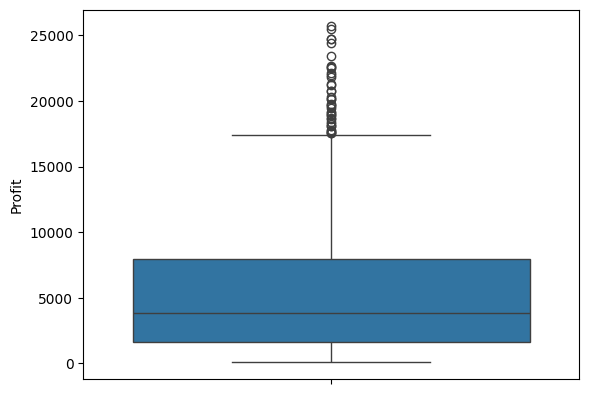

In [ ]:
sns.boxplot(data['Profit'])

# EDA: [Univariate + Bivariate + Real Insights] (Part 3)


Data se insights nikaalenge yehi real data science hai:
EDA FLOW
1. Univariate (1 column)
2. Bivariate (2 columns)
3. Insight (meaning)

Data ko explore karna taake patterns, trends aur relationships samajh aayein

Step 1: UNIVARIATE ANALYSIS

Ek variable ko individually analyze karna by using statistics (Mean , std min/max etc.).
* Agar mean aur median different ho → skewness hai


Numerical Column

In [ ]:
data['Revenue'].median()

20743.015

Distribution

<Axes: >

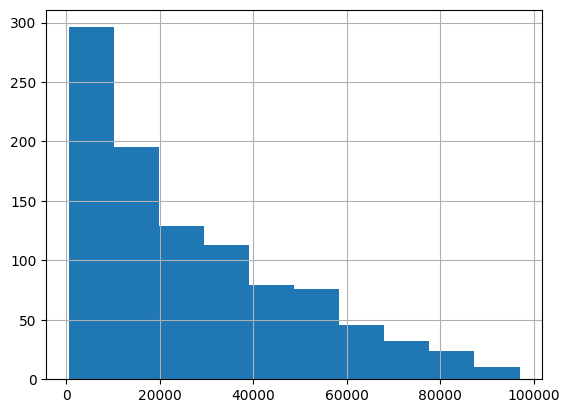

In [ ]:
data["Revenue"].hist()

Categorical Column


In [ ]:
data["Category"].value_counts()

,count
Category,
Electronics,178
Home Decor,172
Beauty Products,168
Fashion,167
Groceries,159
Books,156


<Axes: xlabel='Category'>

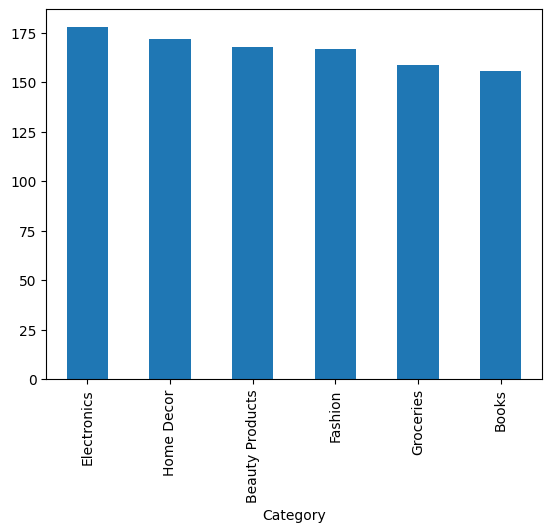

In [ ]:
data["Category"].value_counts().plot(kind="bar")

Step 2: BIVARIATE ANALYSIS

Do variables ke beech relationship samajhna. Real insights nikalna kiya cheez kis ko affect kar rahe hai?

CASE 1: Numerical vs Numerical

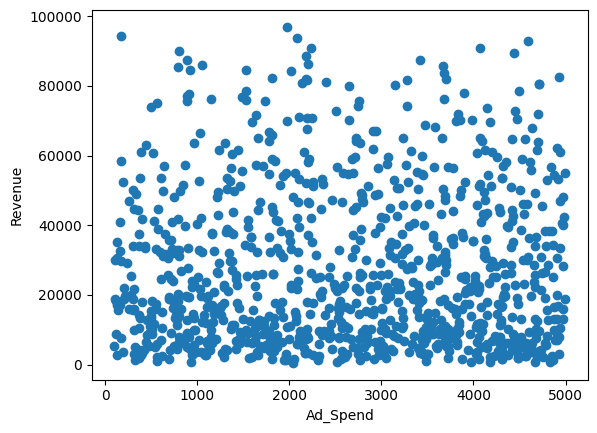

In [ ]:
plt.scatter(data["Ad_Spend"], data["Revenue"])
plt.xlabel("Ad_Spend")
plt.ylabel("Revenue")
plt.show()

CASE 2: Categorical vs Numerical

Har category ka average revenue

In [ ]:
data.groupby("Category")["Revenue"].mean()

,Revenue
Category,
Beauty Products,27970.629107
Books,23825.477115
Electronics,26072.630674
Fashion,25486.162096
Groceries,30119.923899
Home Decor,29194.878895


<Axes: xlabel='Category'>

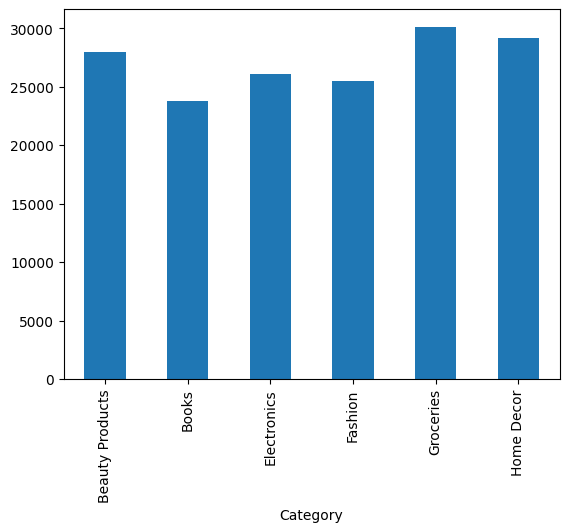

In [ ]:
data.groupby("Category")["Revenue"].mean().plot(kind="bar")

CASE 3: Categorical vs Categorical

Kis category ka kis region mein zyada sale hai

In [ ]:
pd.crosstab(data["Category"], data["Region"])

Region,East,North,South,West
Category,,,,
Beauty Products,46,45,42,35
Books,37,43,38,38
Electronics,41,48,40,49
Fashion,40,40,43,44
Groceries,40,42,47,30
Home Decor,44,51,46,31


# Data Visulization (Part 4)

Data ko graphs ke through is tarah present karna ke insights easily samajh aayein.
>Numbers → Visual → Insight → Decision


Chart Selection:
>(Use Case)	(Best Chart)
1. Distribution	→ Histogram
2. Category comparison → Bar chart
3. Relationship	→ Scatter plot
4. Outliers	→ Boxplot

<Axes: >

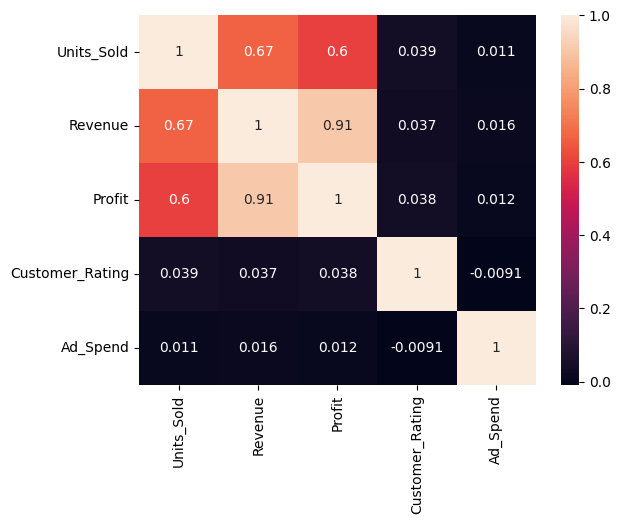

In [ ]:
# variables_relation = ['Units_Sold',	'Revenue',	'Profit',	'Customer_Rating',	'Ad_Spend']
numeric_df = data.select_dtypes(include=['numbers'])
sns.heatmap(data[numeric_df ].corr(), annot=True)

<Axes: xlabel='Category', ylabel='count'>

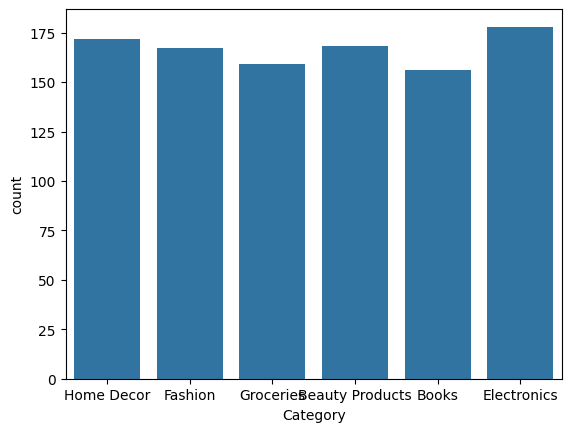

In [ ]:
sns.countplot(x=data["Category"])

# Insight Building (part 5)

Data se meaningful conclusion nikalna.
>Graph → Observation → Insight → Decision

Case 1 Insight: Ad_spend vs Revenue
>Observation: Ads and Revenue is a week relation to eachother.
>
>Insight: Ads are not effcetive, strategy and content are not accomodate with Revenue that why ads don't enhance revenue cost.
>In current scenerio high Ads_spend cost is wasted because high Ad cost don't effect revenue
>
>Decision: Change Ads strategy and content should apply best ads that ehnace revenue.



Case 2 Insight: Category vs Revenue
>Observation: In Current scenerio Groceries have highest revenue.
>
>Insights: Groceries best performing category hai
>
>Decision: Should increase Ads in this category with different ads strategy and content that effect revenue.


Case 3 Insight: Category vs Region
>Observation:Different categories different regions mein different performance dikha rahi hain
>
>Insights:
* Electronics perform highest in the West region.
* Groceries are strong in the South region.
* Home Decor performs highest in the North region.
* Beauty Products sell more in the East region.
>
>Decision: Apply Region-specific Strategy